<a href="https://colab.research.google.com/github/KU-EBL/Data/blob/main/EDS_Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
os.chdir("/content")

In [3]:
!rm -rf /content/Data
!git clone https://github.com/KU-EBL/Data.git

Cloning into 'Data'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 158 (delta 38), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 7.62 MiB | 11.10 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [4]:
import os
os.chdir("/content/Data/EDS")
os.listdir()

['05_groupwise_imputation.csv',
 '07_outlier_detection_practice.csv',
 '09_preprocessing_practice.csv',
 'missing_value_examples.ipynb',
 '04_timeseries_interpolation_kalman.csv',
 '03_categorical_mode_unknown.csv',
 'gradient_boosting_environment_practice.csv',
 '01_few_missing_row_removal.csv',
 '06_high_missingness_remove_variable.csv',
 '02_numeric_mean_median_imputation.csv',
 '08_nonrandom_missingness_investigate.csv',
 '07_measurement_recording_error.csv',
 'gb_classifier_algae_practice_data.csv']

In [5]:
import pandas as pd
df = pd.read_csv('01_few_missing_row_removal.csv')

In [6]:
df

,site_id,temperature_C,rainfall_mm,pm25_ug_m3
0,S01,18.2,12.0,22.1
1,S02,19.4,8.5,24.7
2,S03,NaN,15.2,21.8
3,S04,20.1,0.0,25.3
4,S05,21.0,4.2,23.9
5,S06,19.8,7.4,NaN
6,S07,18.9,10.1,20.6
7,S08,20.4,2.8,24.2


In [7]:
df.isna()

,site_id,temperature_C,rainfall_mm,pm25_ug_m3
0,False,False,False,False
1,False,False,False,False
2,False,True,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,True
6,False,False,False,False
7,False,False,False,False


In [8]:
df.isna().sum()

,0
site_id,0
temperature_C,1
rainfall_mm,0
pm25_ug_m3,1


In [9]:
missing_ratio = df.isna().mean() * 100
missing_ratio

,0
site_id,0.0
temperature_C,12.5
rainfall_mm,0.0
pm25_ug_m3,12.5


In [15]:
import pandas as pd
df = pd.read_csv('01_few_missing_row_removal.csv')
print("Before: ", df.shape)
df

Before:  (8, 4)


,site_id,temperature_C,rainfall_mm,pm25_ug_m3
0,S01,18.2,12.0,22.1
1,S02,19.4,8.5,24.7
2,S03,NaN,15.2,21.8
3,S04,20.1,0.0,25.3
4,S05,21.0,4.2,23.9
5,S06,19.8,7.4,NaN
6,S07,18.9,10.1,20.6
7,S08,20.4,2.8,24.2


In [17]:
df_clean = df.dropna()
print("Before: ", df_clean.shape)
df

Before:  (6, 4)


,site_id,temperature_C,rainfall_mm,pm25_ug_m3
0,S01,18.2,12.0,22.1
1,S02,19.4,8.5,24.7
2,S03,NaN,15.2,21.8
3,S04,20.1,0.0,25.3
4,S05,21.0,4.2,23.9
5,S06,19.8,7.4,NaN
6,S07,18.9,10.1,20.6
7,S08,20.4,2.8,24.2


In [19]:
df = pd.read_csv('02_numeric_mean_median_imputation.csv')
df

,site_id,land_use,soil_moisture_pct
0,S01,Forest,31.2
1,S02,Forest,29.8
2,S03,Agriculture,NaN
3,S04,Urban,18.5
4,S05,Agriculture,24.7
5,S06,Forest,NaN
6,S07,Urban,17.9
7,S08,Agriculture,25.1


In [20]:
df = pd.read_csv('02_numeric_mean_median_imputation.csv')
df["soil_moisture_pct"] = df["soil_moisture_pct"].fillna(df["soil_moisture_pct"].mean())
df

,site_id,land_use,soil_moisture_pct
0,S01,Forest,31.200000
1,S02,Forest,29.800000
2,S03,Agriculture,24.533333
3,S04,Urban,18.500000
4,S05,Agriculture,24.700000
5,S06,Forest,24.533333
6,S07,Urban,17.900000
7,S08,Agriculture,25.100000


In [21]:
df = pd.read_csv('02_numeric_mean_median_imputation.csv')
df["soil_moisture_pct"] = df["soil_moisture_pct"].fillna(df["soil_moisture_pct"].median())
df

,site_id,land_use,soil_moisture_pct
0,S01,Forest,31.2
1,S02,Forest,29.8
2,S03,Agriculture,24.9
3,S04,Urban,18.5
4,S05,Agriculture,24.7
5,S06,Forest,24.9
6,S07,Urban,17.9
7,S08,Agriculture,25.1


In [22]:
df = pd.read_csv('03_categorical_mode_unknown.csv')
df

,site_id,land_use,temperature_C
0,S01,Forest,18.2
1,S02,Agriculture,20.4
2,S03,NaN,21.1
3,S04,Urban,23.0
4,S05,Forest,17.9
5,S06,NaN,19.8
6,S07,Forest,18.5
7,S08,Agriculture,20.0


In [25]:
mode_value = df["land_use"].mode()
print(mode_value)
print(mode_value[0]) # df["land_use"].mode()[0]

0    Forest
Name: land_use, dtype: object
Forest


In [27]:
df["land_use"] = df["land_use"].fillna(mode_value[0])
df

,site_id,land_use,temperature_C
0,S01,Forest,18.2
1,S02,Agriculture,20.4
2,S03,Forest,21.1
3,S04,Urban,23.0
4,S05,Forest,17.9
5,S06,Forest,19.8
6,S07,Forest,18.5
7,S08,Agriculture,20.0


In [29]:
df = pd.read_csv('03_categorical_mode_unknown.csv')
df["land_use"] = df["land_use"].fillna("Unknown")
df

,site_id,land_use,temperature_C
0,S01,Forest,18.2
1,S02,Agriculture,20.4
2,S03,Unknown,21.1
3,S04,Urban,23.0
4,S05,Forest,17.9
5,S06,Unknown,19.8
6,S07,Forest,18.5
7,S08,Agriculture,20.0


In [31]:
df = pd.read_csv('03_categorical_mode_unknown.csv')

# 1. Select rows with both land use type and temperature available
known = df.dropna(subset=["land_use", "temperature_C"])

# 2. Select rows with missing land use type but available temperature
missing = df.index[
    df["land_use"].isna() & df["temperature_C"].notna()]

# 3. Fill missing land use types using the row with the closest temperature
for idx in missing:
    difference = (
        known["temperature_C"] - df.loc[idx, "temperature_C"]
    ).abs()

    nearest_idx = difference.idxmin()
    df.loc[idx, "land_use"] = known.loc[nearest_idx, "land_use"]

df

,site_id,land_use,temperature_C
0,S01,Forest,18.2
1,S02,Agriculture,20.4
2,S03,Agriculture,21.1
3,S04,Urban,23.0
4,S05,Forest,17.9
5,S06,Agriculture,19.8
6,S07,Forest,18.5
7,S08,Agriculture,20.0


In [38]:
!pip install -q pykalman
import numpy as np
from pykalman import KalmanFilter

df = pd.read_csv("04_timeseries_interpolation_kalman.csv", parse_dates = ["datetime"])
df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.1 MB/s eta 0:00:00


,datetime,temperature_C
0,2026-07-01 00:00:00,22.1
1,2026-07-01 01:00:00,21.8
2,2026-07-01 02:00:00,21.5
3,2026-07-01 03:00:00,NaN
4,2026-07-01 04:00:00,NaN
5,2026-07-01 05:00:00,20.9
6,2026-07-01 06:00:00,21.3
7,2026-07-01 07:00:00,NaN
8,2026-07-01 08:00:00,23.2
9,2026-07-01 09:00:00,24.6


In [39]:
df_int = df.copy()
df_int["temperature_C"] = df_int["temperature_C"].interpolate()
df_int

,datetime,temperature_C
0,2026-07-01 00:00:00,22.10
1,2026-07-01 01:00:00,21.80
2,2026-07-01 02:00:00,21.50
3,2026-07-01 03:00:00,21.30
4,2026-07-01 04:00:00,21.10
5,2026-07-01 05:00:00,20.90
6,2026-07-01 06:00:00,21.30
7,2026-07-01 07:00:00,22.25
8,2026-07-01 08:00:00,23.20
9,2026-07-01 09:00:00,24.60


In [40]:
df_kal = df.copy()
values = df_kal["temperature_C"].to_numpy(dtype=float)
masked_values = np.ma.masked_invalid(values)

kf = KalmanFilter(
    initial_state_mean = np.nanmean(values),
    initial_state_covariance=1.0,
    observation_covariance = 1.0,
    transition_covariance = 0.1
)

state_means, _ = kf.smooth(masked_values)
kalman_values = state_means.ravel()

missing_mask = df_kal["temperature_C"].isna()

df_kal.loc[missing_mask, "temperature_C"] = kalman_values[missing_mask]

df_kal

,datetime,temperature_C
0,2026-07-01 00:00:00,22.100000
1,2026-07-01 01:00:00,21.800000
2,2026-07-01 02:00:00,21.500000
3,2026-07-01 03:00:00,22.363153
4,2026-07-01 04:00:00,22.440277
5,2026-07-01 05:00:00,20.900000
6,2026-07-01 06:00:00,21.300000
7,2026-07-01 07:00:00,23.140755
8,2026-07-01 08:00:00,23.200000
9,2026-07-01 09:00:00,24.600000


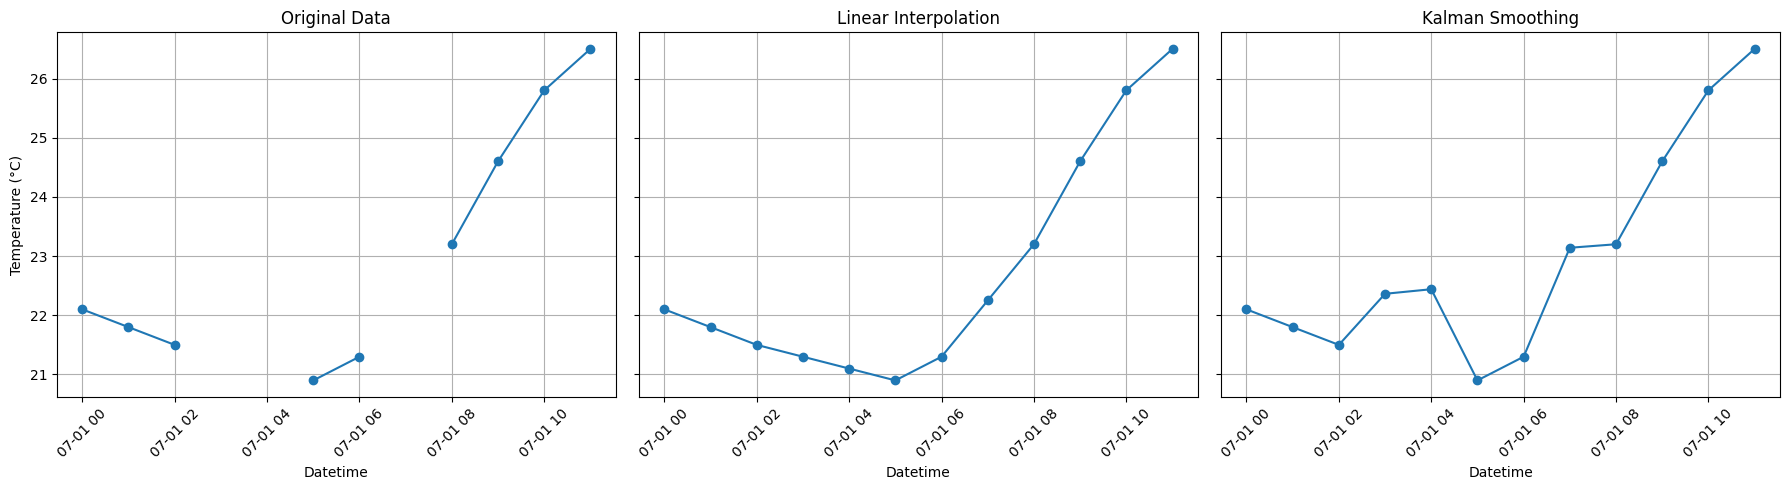

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 1. Original data
axes[0].plot(
    df["datetime"],
    df["temperature_C"],
    marker="o"
)

axes[0].set_title("Original Data")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Temperature (°C)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True)

# 2. Interpolation
axes[1].plot(
    df_int["datetime"],
    df_int["temperature_C"],
    marker="o"
)

axes[1].set_title("Linear Interpolation")
axes[1].set_xlabel("Datetime")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True)

# 3. Kalman smoothing
axes[2].plot(
    df_kal["datetime"],
    df_kal["temperature_C"],
    marker="o"
)

axes[2].set_title("Kalman Smoothing")
axes[2].set_xlabel("Datetime")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [42]:
df = pd.read_csv("05_groupwise_imputation.csv")
df

,site_id,land_use,soil_moisture_pct
0,S01,Forest,32.1
1,S02,Forest,30.4
2,S03,Forest,NaN
3,S04,Agriculture,24.0
4,S05,Agriculture,25.2
5,S06,Agriculture,NaN
6,S07,Urban,16.8
7,S08,Urban,18.1
8,S09,Urban,NaN


In [43]:
df_grp = df.copy()

group_mean = df_grp.groupby("land_use")["soil_moisture_pct"].transform("mean")

df_grp["soil_moisture_pct"] = df_grp["soil_moisture_pct"].fillna(group_mean)

df_grp

,site_id,land_use,soil_moisture_pct
0,S01,Forest,32.10
1,S02,Forest,30.40
2,S03,Forest,31.25
3,S04,Agriculture,24.00
4,S05,Agriculture,25.20
5,S06,Agriculture,24.60
6,S07,Urban,16.80
7,S08,Urban,18.10
8,S09,Urban,17.45


In [45]:
df = pd.read_csv("06_high_missingness_remove_variable.csv")
df

,site_id,temperature_C,rainfall_mm,nitrate_mg_L
0,S01,18.2,12.0,NaN
1,S02,19.4,8.5,NaN
2,S03,20.1,15.2,2.1
3,S04,20.8,0.0,NaN
4,S05,21.0,4.2,NaN
5,S06,19.8,7.4,NaN
6,S07,18.9,10.1,1.8
7,S08,20.4,2.8,NaN
8,S09,21.3,1.5,NaN
9,S10,22.0,0.0,NaN


In [46]:
# Calculate the percentage of missing values in each column
missing_ratio = df.isna().mean() * 100
print(missing_ratio)

# Drop columns with more than 50% missing values
threshold = 50
cols_to_drop = missing_ratio[missing_ratio > threshold].index
df_reduced = df.drop(columns=cols_to_drop)

print("Dropped columns:", list(cols_to_drop))
df_reduced

site_id           0.0
temperature_C     0.0
rainfall_mm       0.0
nitrate_mg_L     80.0
dtype: float64
Dropped columns: ['nitrate_mg_L']


,site_id,temperature_C,rainfall_mm
0,S01,18.2,12.0
1,S02,19.4,8.5
2,S03,20.1,15.2
3,S04,20.8,0.0
4,S05,21.0,4.2
5,S06,19.8,7.4
6,S07,18.9,10.1
7,S08,20.4,2.8
8,S09,21.3,1.5
9,S10,22.0,0.0


In [48]:
df = pd.read_csv("07_outlier_detection_practice.csv")
df

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L
0,S01,18.2,7.1,2.1,8.2
1,S02,19.1,7.3,2.5,8.0
2,S03,20.3,7.0,1.9,7.9
3,S04,21.0,7.4,2.8,8.3
4,S05,18.8,7.2,2.3,8.1
5,S06,19.7,7.1,2.2,8.4
6,S07,20.1,7.5,2.6,7.8
7,S08,21.5,7.3,2.4,8.0
8,S09,19.3,7.0,2.0,8.2
9,S10,20.0,7.2,2.7,8.1


In [49]:
rule_temp_outliers = df[
    (df["temperature_C"] < -5) |
    (df["temperature_C"] > 50)
]

rule_temp_outliers

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L
14,S15,-80.0,7.2,2.4,8.0


In [50]:
df1 = df.copy()
df1 = df1.drop(index=rule_temp_outliers.index)

df1

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L
0,S01,18.2,7.1,2.1,8.2
1,S02,19.1,7.3,2.5,8.0
2,S03,20.3,7.0,1.9,7.9
3,S04,21.0,7.4,2.8,8.3
4,S05,18.8,7.2,2.3,8.1
5,S06,19.7,7.1,2.2,8.4
6,S07,20.1,7.5,2.6,7.8
7,S08,21.5,7.3,2.4,8.0
8,S09,19.3,7.0,2.0,8.2
9,S10,20.0,7.2,2.7,8.1


In [51]:
# Load the data
df = pd.read_csv("07_outlier_detection_practice.csv")

# Calculate the first and third quartiles
Q1 = df["nitrate_mg_L"].quantile(0.25)
Q3 = df["nitrate_mg_L"].quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# 5. Identify nitrate values outside the bounds
iqr_outliers = df[
    (df["nitrate_mg_L"] < lower_bound) |
    (df["nitrate_mg_L"] > upper_bound)
]

iqr_outliers

Lower bound: 1.5500000000000012
Upper bound: 3.149999999999999


,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L
10,S11,45.0,7.4,15.0,2.0


In [52]:
# Remove rows containing the identified nitrate outliers
df_iqr = df.drop(index=iqr_outliers.index)

df_iqr

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L
0,S01,18.2,7.1,2.1,8.2
1,S02,19.1,7.3,2.5,8.0
2,S03,20.3,7.0,1.9,7.9
3,S04,21.0,7.4,2.8,8.3
4,S05,18.8,7.2,2.3,8.1
5,S06,19.7,7.1,2.2,8.4
6,S07,20.1,7.5,2.6,7.8
7,S08,21.5,7.3,2.4,8.0
8,S09,19.3,7.0,2.0,8.2
9,S10,20.0,7.2,2.7,8.1


In [53]:
import pandas as pd
from scipy.stats import zscore

# Load the data
df = pd.read_csv("07_outlier_detection_practice.csv")

# Calculate z-scores for temperature
df["temperature_zscore"] = zscore(df["temperature_C"])

# Display temperature values and their z-scores
df[["site_id", "temperature_C", "temperature_zscore"]]

,site_id,temperature_C,temperature_zscore
0,S01,18.2,0.131239
1,S02,19.1,0.165708
2,S03,20.3,0.211667
3,S04,21.0,0.238476
4,S05,18.8,0.154218
5,S06,19.7,0.188687
6,S07,20.1,0.204007
7,S08,21.5,0.257626
8,S09,19.3,0.173368
9,S10,20.0,0.200177


In [54]:
# Identify temperature outliers with an absolute z-score greater than 3
zscore_outliers = df[
    df["temperature_zscore"].abs() > 3
]

zscore_outliers

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L,temperature_zscore
14,S15,-80.0,7.2,2.4,8.0,-3.629742


In [ ]:
import numpy as np

x = df["temperature_C"]

# Calculate the median
median = x.median()

# Calculate the median absolute deviation (MAD)
MAD = np.median(np.abs(x - median))

# Calculate modified z-scores
df["modified_zscore"] = 0.6745 * (x - median) / MAD

# Identify potential outliers with an absolute modified z-score greater than 3.5
modified_z_outliers = df[
    df["modified_zscore"].abs() > 3.5
]

modified_z_outliers

In [56]:
df_modified = df.drop(index=modified_z_outliers.index)

df_modified

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L,temperature_zscore,modified_zscore
0,S01,18.2,7.1,2.1,8.2,0.131239,-1.686250
1,S02,19.1,7.3,2.5,8.0,0.165708,-0.674500
2,S03,20.3,7.0,1.9,7.9,0.211667,0.674500
3,S04,21.0,7.4,2.8,8.3,0.238476,1.461417
4,S05,18.8,7.2,2.3,8.1,0.154218,-1.011750
5,S06,19.7,7.1,2.2,8.4,0.188687,0.000000
6,S07,20.1,7.5,2.6,7.8,0.204007,0.449667
7,S08,21.5,7.3,2.4,8.0,0.257626,2.023500
8,S09,19.3,7.0,2.0,8.2,0.173368,-0.449667
9,S10,20.0,7.2,2.7,8.1,0.200177,0.337250


In [57]:
lower_percentile = df["nitrate_mg_L"].quantile(0.05)
upper_percentile = df["nitrate_mg_L"].quantile(0.95)

print("Lower threshold:", lower_percentile)
print("Upper threshold:", upper_percentile)

Lower threshold: 1.97
Upper threshold: 6.459999999999987


In [58]:
percentile_outliers = df[
    (df["nitrate_mg_L"] < lower_percentile) |
    (df["nitrate_mg_L"] > upper_percentile)
]

percentile_outliers

,site_id,temperature_C,pH,nitrate_mg_L,DO_mg_L,temperature_zscore,modified_zscore
2,S03,20.3,7.0,1.9,7.9,0.211667,0.674500
10,S11,45.0,7.4,15.0,2.0,1.157657,28.441417


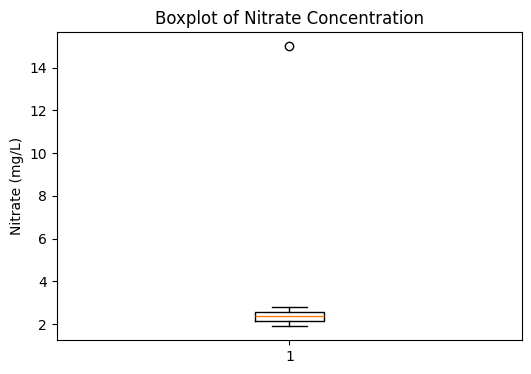

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.boxplot(df["nitrate_mg_L"])

plt.ylabel("Nitrate (mg/L)")
plt.title("Boxplot of Nitrate Concentration")

plt.show()

In [60]:
from sklearn.ensemble import IsolationForest

df_iso = df.copy()

# Select variables for multivariate outlier detection
features = [
    "temperature_C",
    "pH",
    "nitrate_mg_L",
    "DO_mg_L"
]

X = df_iso[features]

In [ ]:
# Fit the Isolation Forest model and predict outlier labels
model = IsolationForest(
    contamination=0.15,
    random_state=42
)

# Labels: 1 = inlier, -1 = outlier
df_iso["isolation_result"] = model.fit_predict(X)

df_iso

In [ ]:
# Select rows identified as outliers
isolation_outliers = df_iso[
    df_iso["isolation_result"] == -1
]

isolation_outliers

# Week2 & 3

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("09_preprocessing_practice.csv")
df.head()

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x = df["nitrate_mg_L"].dropna()

# Visualize the original distribution
plt.figure(figsize=(6, 4))
plt.hist(x, bins=8, density=True, alpha=0.6)

kde = gaussian_kde(x)
x_range = np.linspace(x.min(), x.max(), 200)
plt.plot(x_range, kde(x_range), linewidth=2)

plt.xlabel("Nitrate (mg/L)")
plt.ylabel("Density")
plt.title("Original Distribution with Trend Curve")

plt.show()

In [ ]:
df["nitrate_log"] = np.log1p(df["nitrate_mg_L"])

x = df["nitrate_log"].dropna()

# Visualize the log-transformed distribution
plt.figure(figsize=(6, 4))
plt.hist(x, bins=8, density=True, alpha=0.6)

kde = gaussian_kde(x)
x_range = np.linspace(x.min(), x.max(), 200)
plt.plot(x_range, kde(x_range), linewidth=2)

plt.xlabel("Nitrate (mg/L)")
plt.ylabel("Density")
plt.title("Original Distribution with Trend Curve")

plt.show()

In [ ]:
df = pd.read_csv("09_preprocessing_practice.csv")
df[["temperature_C", "rainfall_mm"]]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
normalized_data = minmax_scaler.fit_transform(
    df[["temperature_C", "rainfall_mm"]]
)
display(normalized_data)

In [ ]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
standardized_data = standard_scaler.fit_transform(
    df[["temperature_C", "rainfall_mm"]]
)
display(standardized_data)

In [ ]:
df

In [ ]:
onehot = pd.get_dummies(df, columns = ['land_use'], dtype = int)
onehot

In [ ]:
df["risk_level_encoded"] = df["risk_level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})
df

In [ ]:
df

In [ ]:
df["land_use_class"] = df.groupby("land_use")["risk_level_encoded"].transform('mean')
df

In [ ]:
def weighted_target_encoding(df, cat_col, target_col, weight):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Input data frame.

    cat_col : str
        Name of the categorical column

    target_col : str
        Name of the target column

    weight : float
        Smoothing weight.
        In this example, the value is set to 2.
    """

    # Calculate the overall target mean
    overall_mean = df[target_col].mean()

    # Calculate the count and mean for each category
    agg = df.groupby(cat_col)[target_col].agg(["count", "mean"])

    counts = agg["count"]   # Number of observations in each category
    means = agg["mean"]     # Mean target value for each category

    # Calculate the smoothed weighted target encoding
    smooth_mean = (
        counts * means + weight * overall_mean
    ) / (
        counts + weight
    )

    # Convert the encoded values into a dictionary
    encoding_mapping = smooth_mean.to_dict()

    # Add the encoded column to the original data frame
    df[cat_col + "_encoded"] = df[cat_col].map(
        encoding_mapping
    )

    return encoding_mapping, df

In [ ]:
 weighted, df_new= weighted_target_encoding(df, "land_use", "risk_level_encoded", 2)

In [ ]:
weighted

In [ ]:
df_new

# Week 4

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
df = pd.read_csv("gradient_boosting_environment_practice.csv")
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["TN_status"],
    dtype=int
)

display(df_encoded.head())

print("Original columns:")
print(df.columns.tolist())

print("\nColumns after one-hot encoding:")
print(df_encoded.columns.tolist())

In [ ]:
feature_cols = [
    "Flow_m3_s",
    "Temperature_C",
    "pH",
    "DO_mg_L",
    "Turbidity_NTU",
    "EC_uS_cm",
    "TN_status_Good"
]

X = df_encoded[feature_cols]
y = df_encoded["TOC_mg_L"]

In [ ]:
# First split: 80% development data and 20% test data
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Second split: development data into 75% training and 25% validation
# This produces 60% train, 20% validation, and 20% test overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=42
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples      :", len(X_test))

In [ ]:
baseline_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    min_samples_leaf=5,
    subsample=1.0,
    loss="squared_error",
    random_state=42
)

baseline_model.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = baseline_model.predict(X_val)

# Evaluate the baseline model
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
val_r2 = r2_score(y_val, y_val_pred)

print("Baseline model performance on the validation set")
print(f"MAE  : {val_mae:.3f}")
print(f"RMSE : {val_rmse:.3f}")
print(f"R²   : {val_r2:.3f}")


In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_val, y_val_pred, alpha=0.75)

minimum = min(y_val.min(), y_val_pred.min())
maximum = max(y_val.max(), y_val_pred.max())

# Draw the 1:1 reference line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Observed TOC (mg/L)")
plt.ylabel("Predicted TOC (mg/L)")
plt.title("Observed vs. Predicted: Validation Set")
plt.tight_layout()
plt.show()

In [ ]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
results = []

for lr in learning_rates:
    comparison_model = GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=lr,
        max_depth=2,
        min_samples_leaf=5,
        random_state=42
    )

    # Train using the training set
    comparison_model.fit(X_train, y_train)

    # Evaluate using the validation set
    val_pred = comparison_model.predict(X_val)

    results.append({
        "learning_rate": lr,
        "MAE": mean_absolute_error(y_val, val_pred),
        "RMSE": mean_squared_error(y_val, val_pred) ** 0.5,
        "R2": r2_score(y_val, val_pred)
    })

learning_rate_results = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(learning_rate_results)

In [ ]:
# Visualize validation RMSE for each learning rate
plt.figure(figsize=(6, 4))

plt.scatter(
    learning_rate_results["learning_rate"],
    learning_rate_results["RMSE"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE by Learning Rate")
plt.tight_layout()
plt.show()

In [ ]:
# Define the Grid Search parameter combinations
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [3, 5, 10],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(
        loss="squared_error",
        random_state=42
    ),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation RMSE:")
print(-grid_search.best_score_)


# Evaluate the best Grid Search model
best_grid_model = grid_search.best_estimator_
grid_pred = best_grid_model.predict(X_test)

grid_mae = mean_absolute_error(y_test, grid_pred)
grid_rmse = mean_squared_error(y_test, grid_pred) ** 0.5
grid_r2 = r2_score(y_test, grid_pred)

print(f"Grid Search MAE  : {grid_mae:.3f}")
print(f"Grid Search RMSE : {grid_rmse:.3f}")
print(f"Grid Search R²   : {grid_r2:.3f}")


# Compare baseline and tuned models
baseline_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Baseline", "Grid Search"],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, grid_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, baseline_pred) ** 0.5,
        mean_squared_error(y_test, grid_pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, grid_pred)
    ]
})

display(comparison)


# Week 06

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

In [ ]:
df = pd.read_csv("gb_classifier_algae_practice_data.csv")
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)

In [ ]:
print("\nMissing values in the original dataset")
print(df.isnull().sum())

In [ ]:
print(df["Algae_Bloom"].value_counts())

In [ ]:
X = df.drop(columns=["Sample_ID", "Algae_Bloom"])
y = df["Algae_Bloom"].map({"No": 0, "Yes": 1})

numeric_features = [
    "Flow_m3_s",
    "Water_Temperature_C",
    "pH",
    "DO_mg_L",
    "Turbidity_NTU",
    "TN_mg_L",
    "TP_mg_L",
    "Rainfall_7d_mm",
]

categorical_features = [
    "Season",
    "Site_type",
    "Extreme_Temperature",
]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

In [ ]:
numeric_imputer = SimpleImputer(
    strategy="median"
)

# Learn median values from the training data
X_train_numeric = numeric_imputer.fit_transform(
    X_train[numeric_features]
)

# Apply the same median values to the test data
X_test_numeric = numeric_imputer.transform(
    X_test[numeric_features]
)

In [ ]:
X_train_numeric = pd.DataFrame(
    X_train_numeric,
    columns=numeric_features,
    index=X_train.index
)

X_test_numeric = pd.DataFrame(
    X_test_numeric,
    columns=numeric_features,
    index=X_test.index
)

In [ ]:
# Create the categorical imputer
categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

# Learn the most frequent categories from the training data
X_train_categorical = categorical_imputer.fit_transform(
    X_train[categorical_features]
)

# Apply the same categories to the test data
X_test_categorical = categorical_imputer.transform(
    X_test[categorical_features]
)

In [ ]:
X_train_categorical = pd.DataFrame(
    X_train_categorical,
    columns=categorical_features,
    index=X_train.index
)

X_test_categorical = pd.DataFrame(
    X_test_categorical,
    columns=categorical_features,
    index=X_test.index
)

In [ ]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Learn categories from the training data
X_train_encoded = encoder.fit_transform(
    X_train_categorical
)

# Apply the same encoding rules to the test data
X_test_encoded = encoder.transform(
    X_test_categorical
)

In [ ]:
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

In [ ]:
X_train_final = pd.concat(
    [
        X_train_numeric,
        X_train_encoded
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_numeric,
        X_test_encoded
    ],
    axis=1
)

In [ ]:
print("Processed training data")
display(X_train_final.head())

print("Processed test data")
display(X_test_final.head())

print("Training shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)

print("Missing values in training data:",
      X_train_final.isnull().sum().sum())

print("Missing values in test data:",
      X_test_final.isnull().sum().sum())

In [ ]:
baseline_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    min_samples_leaf=5,
    subsample=1.0,
    random_state=42
)

baseline_model.fit(
    X_train_final,
    y_train
)

y_pred = baseline_model.predict(X_test_final)
y_prob = baseline_model.predict_proba(X_test_final)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1-score :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))

In [ ]:
print("\nConfusion matrix")
print(confusion_matrix(y_test, y_pred))

In [ ]:
print("\nClassification report")
print(classification_report(y_test, y_pred, target_names=["No bloom", "Bloom"]))

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve: Gradient Boosting Classifier")
plt.tight_layout()
plt.show()